# Phase 2: Tokenization
**Goal:** Convert raw text into numbers that DistilBERT can understand.

## What is a Tokenizer?
A tokenizer splits text into **tokens** (subword pieces), then maps each token to an integer ID.

Example:
```
'unbelievable' → ['un', '##believable'] → [4895, 12475]
```

The `##` prefix means 'this is a continuation of the previous word'.

## Special Tokens DistilBERT Adds Automatically
- `[CLS]` — placed at the **start** of every sequence. Its final hidden state is used for classification.
- `[SEP]` — placed at the **end** of every sequence.
- `[PAD]` — added to shorter sequences so all inputs in a batch are the same length.

## Attention Mask
A binary array: `1` = real token, `0` = padding. The model ignores `0`s so padding does not affect the result.

In [1]:
from transformers import DistilBertTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the DistilBERT tokenizer (downloads ~250MB on first run)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print('Vocabulary size:', tokenizer.vocab_size)

C:\Users\Akki Maharaj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Akki Maharaj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Akki Maharaj\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingf

Vocabulary size: 30522


In [2]:
# Inspect what the tokenizer actually does
sample = "We are hiring a Senior Data Scientist with experience in NLP."

tokens = tokenizer.tokenize(sample)
ids    = tokenizer.convert_tokens_to_ids(tokens)

print('Original text:')
print(' ', sample)
print('\nTokens:')
print(' ', tokens)
print('\nToken IDs:')
print(' ', ids)

Original text:
  We are hiring a Senior Data Scientist with experience in NLP.

Tokens:
  ['we', 'are', 'hiring', 'a', 'senior', 'data', 'scientist', 'with', 'experience', 'in', 'nl', '##p', '.']

Token IDs:
  [2057, 2024, 14763, 1037, 3026, 2951, 7155, 2007, 3325, 1999, 17953, 2361, 1012]


In [3]:
# Full encoding with special tokens
encoded = tokenizer(
    sample,
    max_length=512,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print('Keys returned:', list(encoded.keys()))
print('input_ids shape:', encoded['input_ids'].shape)
print('attention_mask shape:', encoded['attention_mask'].shape)

input_ids = encoded['input_ids'][0].tolist()
attn_mask = encoded['attention_mask'][0].tolist()
token_list = tokenizer.convert_ids_to_tokens(input_ids)

print('\nFirst 15 tokens:')
print(f"{' Token':<20} {'ID':<8} {'Mask'}")
print('-' * 36)
for tok, id_, mask in zip(token_list[:15], input_ids[:15], attn_mask[:15]):
    print(f"{tok:<20} {id_:<8} {mask}")

Keys returned: ['input_ids', 'attention_mask']
input_ids shape: torch.Size([1, 512])
attention_mask shape: torch.Size([1, 512])

First 15 tokens:
 Token               ID       Mask
------------------------------------
[CLS]                101      1
we                   2057     1
are                  2024     1
hiring               14763    1
a                    1037     1
senior               3026     1
data                 2951     1
scientist            7155     1
with                 2007     1
experience           3325     1
in                   1999     1
nl                   17953    1
##p                  2361     1
.                    1012     1
[SEP]                102      1


## Finding the Right max_length
512 is DistilBERT's hard ceiling, but using 512 for every sequence wastes memory.
We will find what length covers 95% of our actual data.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (603 > 512). Running this sequence through the model will result in indexing errors


Median token length : 490
95th percentile     : 512
99th percentile     : 512
Hit 512 token limit : 46.7%


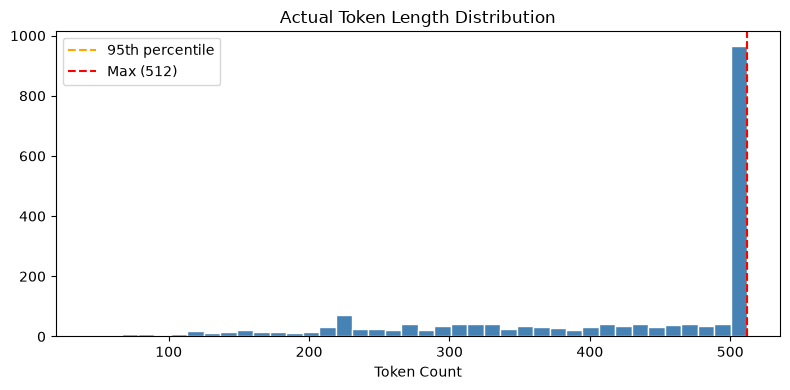

In [4]:
df = pd.read_csv('../data/processed.csv')

# Tokenize a sample to measure actual token lengths
sample_df = df.sample(2000, random_state=42)

token_lengths = []
for text in sample_df['combined_text']:
    tokens = tokenizer.tokenize(str(text))
    token_lengths.append(min(len(tokens) + 2, 512))

token_lengths = np.array(token_lengths)

print(f"Median token length : {np.median(token_lengths):.0f}")
print(f"95th percentile     : {np.percentile(token_lengths, 95):.0f}")
print(f"99th percentile     : {np.percentile(token_lengths, 99):.0f}")
print(f"Hit 512 token limit : {(token_lengths == 512).mean()*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(token_lengths, 95), color='orange',
            linestyle='--', label='95th percentile')
plt.axvline(512, color='red', linestyle='--', label='Max (512)')
plt.title('Actual Token Length Distribution')
plt.xlabel('Token Count')
plt.legend()
plt.tight_layout()
plt.savefig('../data/token_length_distribution.png', dpi=150)
plt.show()

In [5]:
# Save tokenizer for reuse in training
tokenizer.save_pretrained('../models/tokenizer')
print('Tokenizer saved to ../models/tokenizer/')

Tokenizer saved to ../models/tokenizer/
